# Compare corrected v2 runs

This is the validation-results dashboard for protocol v2. It loads only completed v2 runs, checks the experiment grid, builds the predeclared tables, and creates two groups of figures:

1. **Report-ready:** learning trajectories, forgetting, final performance, retention/plasticity, paired confidence intervals, and cost.
2. **Diagnostic:** pair outcomes, margin-change distributions, replay behavior, training curves, and metric sensitivity.

All plotting code stays in notebook cells so it is easy to change. Validation results remain preliminary until both orders and both seeds are complete. Do not use test data here.

## 1. Setup and controls

Change `FOCUS_ORDER` and `FOCUS_SEED` to inspect one matched experiment cell. `SAVE_FIGURES = True` writes 300-DPI PNG and vector PDF copies to Drive.

In [7]:
import os
import sys
import json
import subprocess
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

In [8]:
import importlib.util

# Locate or download the repository.
if os.path.exists("/content"):
    REPO = "/content/mfr-dpo"
    repo_path = Path(REPO)

    analysis_file = repo_path / "src" / "mfr_analysis.py"

    if not analysis_file.is_file():
        if repo_path.exists() and any(repo_path.iterdir()):
            raise FileNotFoundError(
                f"{REPO} exists but does not contain src/mfr_analysis.py. "
                "Use a fresh Colab runtime or inspect that folder."
            )

        print("Repository not found; cloning it now...")

        subprocess.run(
            [
                "git",
                "clone",
                "-q",
                "https://github.com/prabudhd2003/mfr-dpo.git",
                REPO,
            ],
            check=True,
        )

    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_DIR = "/content/drive/MyDrive/CSCI544/mfr-dpo"

else:
    here = Path.cwd().resolve()
    repo_path = here if (here / "src").exists() else here.parent

    REPO = str(repo_path)
    DRIVE_DIR = os.environ.get(
        "MFR_DRIVE_DIR",
        str(repo_path.parent / "drive"),
    )

# Verify the exact analysis file.
analysis_file = Path(REPO) / "src" / "mfr_analysis.py"

if not analysis_file.is_file():
    raise FileNotFoundError(
        f"Could not find {analysis_file}. "
        f"Repository path is currently {REPO}."
    )

# Make project modules available to Python.
source_dir = str(Path(REPO) / "src")

if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

# Load the file directly to avoid Colab/VS Code module-cache problems.
importlib.invalidate_caches()

analysis_spec = importlib.util.spec_from_file_location(
    "mfr_analysis",
    analysis_file,
)

if analysis_spec is None or analysis_spec.loader is None:
    raise ImportError(f"Could not load {analysis_file}")

mfr_analysis = importlib.util.module_from_spec(analysis_spec)
sys.modules["mfr_analysis"] = mfr_analysis
analysis_spec.loader.exec_module(mfr_analysis)

print(f"Loaded analysis code from: {analysis_file}")
print(f"Results directory: {DRIVE_DIR}/runs")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded analysis code from: /content/mfr-dpo/src/mfr_analysis.py
Results directory: /content/drive/MyDrive/CSCI544/mfr-dpo/runs


In [9]:
# ---------- Controls you can change ----------
FOCUS_ORDER = 1
FOCUS_SEED = 0
INCLUDE_LOWEST_MARGIN = True
SAVE_FIGURES = False

In [10]:
protocol_path = Path(REPO) / "configs" / "experiment_protocol.json"

with open(protocol_path, encoding="utf-8") as handle:
    protocol = json.load(handle)

ORDER_NAMES = {
    int(order_id): " → ".join(order)
    for order_id, order in protocol["orders"].items()
}

METHOD_ORDER = [
    "none",
    "random",
    "random_high",
    "lowest_margin",
    "mfr",
]

METHOD_LABEL = {
    "none": "No replay",
    "random": "Random (10%)",
    "random_high": "Random high (14.3%)",
    "lowest_margin": "Lowest margin (10%)",
    "mfr": "MFR (10%)",
}

METHOD_COLOR = {
    "none": "#6b6a66",
    "random": "#2a78d6",
    "random_high": "#7857c5",
    "lowest_margin": "#1b9e77",
    "mfr": "#e66101",
}

DATASET_LABEL = {
    "helpful": "Helpful",
    "safe": "Safe",
    "quality": "Quality",
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "figure.facecolor": "white",
    }
)

FIGURE_DIR = Path(DRIVE_DIR) / "figures" / "validation"
TABLE_DIR = Path(DRIVE_DIR) / "tables" / "validation"

if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_DIR.mkdir(parents=True, exist_ok=True)


def available_methods(frame):
    """Return available methods in a consistent plotting order."""
    present = set(frame["method"].astype(str))

    return [
        method
        for method in METHOD_ORDER
        if method in present
        and (INCLUDE_LOWEST_MARGIN or method != "lowest_margin")
    ]


def finish_figure(fig, filename):
    """Display a figure and optionally save PNG and PDF copies."""
    fig.tight_layout()

    if SAVE_FIGURES:
        png_path = FIGURE_DIR / f"{filename}.png"
        pdf_path = FIGURE_DIR / f"{filename}.pdf"

        fig.savefig(png_path, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")

        print(f"Saved: {png_path}")
        print(f"Saved: {pdf_path}")

    plt.show()


def grouped_bars(
    ax,
    table,
    ylabel,
    title,
    value_format="{:.1f}",
):
    """Draw consistently styled grouped bars."""
    methods = [
        method
        for method in available_methods(runs)
        if method in table.columns
    ]

    x = np.arange(len(table.index))
    width = 0.82 / max(1, len(methods))

    for method_index, method in enumerate(methods):
        offset = (
            method_index - (len(methods) - 1) / 2
        ) * width

        values = table[method].to_numpy(float)

        bars = ax.bar(
            x + offset,
            values,
            width,
            color=METHOD_COLOR[method],
            label=METHOD_LABEL[method],
        )

        labels = [
            value_format.format(value)
            if np.isfinite(value)
            else ""
            for value in values
        ]

        ax.bar_label(
            bars,
            labels=labels,
            padding=2,
            fontsize=8,
        )

    ax.set_xticks(
        x,
        [
            DATASET_LABEL.get(str(value), str(value))
            for value in table.index
        ],
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)

    return methods

In [11]:
# Load completed protocol-v2 runs from Drive.
runs = mfr_analysis.load_runs(
    DRIVE_DIR,
    include_preliminary=False,
    completed_only=True,
)

# Warn about missing matched cells without stopping partial analysis.
mfr_analysis.validate_compatible_runs(
    runs,
    strict=False,
)

focus = runs[
    (runs["order_id"] == FOCUS_ORDER)
    & (runs["seed"] == FOCUS_SEED)
].copy()

if focus.empty:
    raise ValueError(
        f"No completed runs were found for "
        f"order {FOCUS_ORDER}, seed {FOCUS_SEED}."
    )

print(
    f"Focus: order {FOCUS_ORDER} "
    f"({ORDER_NAMES[FOCUS_ORDER]}), "
    f"seed {FOCUS_SEED}"
)

if SAVE_FIGURES:
    print(f"Figures will be saved to: {FIGURE_DIR}")
    print(f"Tables will be saved to: {TABLE_DIR}")
else:
    print("Figure and table saving is turned off.")

5 runs found
  v2_o1_lowest_margin_s0       stages finished: 3/3
  v2_o1_mfr_s0                 stages finished: 3/3
  v2_o1_none_s0                stages finished: 3/3
  v2_o1_random_high_s0         stages finished: 3/3
  v2_o1_random_s0              stages finished: 3/3
Focus: order 1 (helpful → safe → quality), seed 0
Figure and table saving is turned off.


## 2. Predeclared result tables

`mean_retention_change` is final minus immediately-after-learning accuracy, so values closer to zero are better. The primary comparison is MFR versus equal-budget random replay.

In [13]:
primary_summary = mfr_analysis.summary_table(runs, score='accuracy')
primary_retention = mfr_analysis.retention_table(runs, score='accuracy')
primary_learning = mfr_analysis.new_learning_table(runs, score='accuracy')
secondary_summary = mfr_analysis.summary_table(runs, score='accuracy_sum')

display(Markdown('### Primary: length-normalized relative accuracy'))
display(primary_summary.round(2))
display(Markdown('### Retention by old behavior'))
display(primary_retention.round(2))
display(Markdown('### New-stage learning'))
display(primary_learning.round(2))
display(Markdown('### Required secondary metric: summed relative accuracy'))
display(secondary_summary.round(2))

core = primary_summary[primary_summary['method'].astype(str).isin(['random', 'mfr'])].copy()
core['method'] = core['method'].astype(str)
core = core.pivot(index=['order_id', 'seed'], columns='method',
                  values=['mean_retention_change', 'final_new_stage_score'])
decision_rows = []
for cell, row in core.dropna().iterrows():
    retention_advantage = row[('mean_retention_change', 'mfr')] - row[('mean_retention_change', 'random')]
    plasticity_gap = row[('final_new_stage_score', 'mfr')] - row[('final_new_stage_score', 'random')]
    decision_rows.append({
        'order_id': cell[0], 'seed': cell[1],
        'MFR retention advantage (points)': retention_advantage,
        'MFR final-task gap (points)': plasticity_gap,
        'within 2-point learning tolerance': plasticity_gap >= -protocol['new_learning_tolerance_points'],
    })
decision = pd.DataFrame(decision_rows)
display(Markdown('### Frozen success-rule check'))
display(decision.round(2))

if SAVE_FIGURES:
    primary_summary.to_csv(TABLE_DIR / 'primary_summary.csv', index=False)
    primary_retention.to_csv(TABLE_DIR / 'primary_retention.csv', index=False)
    primary_learning.to_csv(TABLE_DIR / 'primary_new_learning.csv', index=False)
    secondary_summary.to_csv(TABLE_DIR / 'secondary_summary.csv', index=False)
    decision.to_csv(TABLE_DIR / 'success_rule_by_cell.csv', index=False)

### Primary: length-normalized relative accuracy

,run_name,order_id,method,seed,mean_retention_change,worst_retention_change,mean_margin_kept_pct,mean_new_stage_gain,final_new_stage_score
0,v2_o1_lowest_margin_s0,1,lowest_margin,0,-4.50,-6.5,122.10,25.83,74.0
1,v2_o1_mfr_s0,1,mfr,0,-5.00,-6.0,123.21,28.00,76.5
2,v2_o1_none_s0,1,none,0,-8.00,-9.5,110.94,25.83,74.5
3,v2_o1_random_s0,1,random,0,-5.75,-6.0,120.28,26.00,74.0
4,v2_o1_random_high_s0,1,random_high,0,-5.25,-5.5,123.41,26.67,75.0


### Retention by old behavior

,run_name,order_id,method,seed,dataset,learned_at,right_after,at_end,change,margin_kept
0,v2_o1_lowest_margin_s0,1,lowest_margin,0,helpful,1,70.0,63.5,-6.5,168.24
1,v2_o1_lowest_margin_s0,1,lowest_margin,0,safe,2,81.5,79.0,-2.5,75.96
2,v2_o1_mfr_s0,1,mfr,0,helpful,1,70.0,64.0,-6.0,170.90
3,v2_o1_mfr_s0,1,mfr,0,safe,2,82.0,78.0,-4.0,75.52
4,v2_o1_none_s0,1,none,0,helpful,1,70.0,63.5,-6.5,169.57
5,v2_o1_none_s0,1,none,0,safe,2,83.5,74.0,-9.5,52.31
6,v2_o1_random_high_s0,1,random_high,0,helpful,1,70.0,64.5,-5.5,175.33
7,v2_o1_random_high_s0,1,random_high,0,safe,2,82.0,77.0,-5.0,71.50
8,v2_o1_random_s0,1,random,0,helpful,1,70.0,64.0,-6.0,173.41
9,v2_o1_random_s0,1,random,0,safe,2,82.0,76.5,-5.5,67.14


### New-stage learning

,run_name,order_id,method,seed,stage,dataset,before,after,gain
0,v2_o1_lowest_margin_s0,1,lowest_margin,0,1,helpful,37.0,70.0,33.0
1,v2_o1_lowest_margin_s0,1,lowest_margin,0,2,safe,45.5,81.5,36.0
2,v2_o1_lowest_margin_s0,1,lowest_margin,0,3,quality,65.5,74.0,8.5
3,v2_o1_mfr_s0,1,mfr,0,1,helpful,37.0,70.0,33.0
4,v2_o1_mfr_s0,1,mfr,0,2,safe,45.5,82.0,36.5
5,v2_o1_mfr_s0,1,mfr,0,3,quality,62.0,76.5,14.5
6,v2_o1_none_s0,1,none,0,1,helpful,37.0,70.0,33.0
7,v2_o1_none_s0,1,none,0,2,safe,45.5,83.5,38.0
8,v2_o1_none_s0,1,none,0,3,quality,68.0,74.5,6.5
9,v2_o1_random_high_s0,1,random_high,0,1,helpful,37.0,70.0,33.0


### Required secondary metric: summed relative accuracy

,run_name,order_id,method,seed,mean_retention_change,worst_retention_change,mean_margin_kept_pct,mean_new_stage_gain,final_new_stage_score
0,v2_o1_lowest_margin_s0,1,lowest_margin,0,-5.00,-6.0,122.10,31.83,78.0
1,v2_o1_mfr_s0,1,mfr,0,-5.50,-7.5,123.21,31.00,77.0
2,v2_o1_none_s0,1,none,0,-7.25,-8.5,110.94,32.33,78.0
3,v2_o1_random_s0,1,random,0,-8.00,-9.0,120.28,31.67,78.5
4,v2_o1_random_high_s0,1,random_high,0,-6.25,-8.0,123.41,30.83,76.5


### Frozen success-rule check

,order_id,seed,MFR retention advantage (points),MFR final-task gap (points),within 2-point learning tolerance
0,1,0,0.75,2.5,True


# Report-ready figures

These use validation data only. Keep individual order/seed points visible; do not present a one-cell result as a general conclusion.

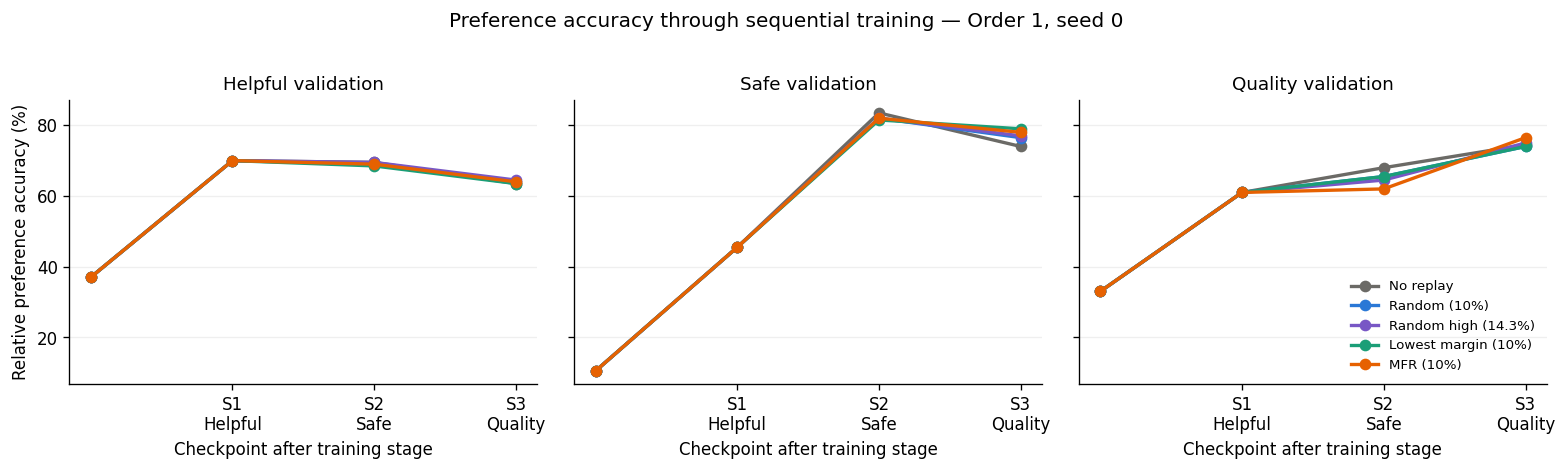

In [14]:
methods = available_methods(focus)
datasets = ['helpful', 'safe', 'quality']
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8), sharey=True)
for ax, dataset in zip(axes, datasets):
    for method in methods:
        part = focus[(focus['method'].astype(str) == method) & (focus['eval_set'] == dataset)].sort_values('stage')
        ax.plot(part['stage'], part['accuracy'], marker='o', linewidth=2,
                color=METHOD_COLOR[method], label=METHOD_LABEL[method])
    stage_names = protocol['orders'][str(FOCUS_ORDER)]
    ax.set_xticks([1, 2, 3], [f'S{i}\n{DATASET_LABEL[name]}' for i, name in enumerate(stage_names, 1)])
    ax.set_title(f'{DATASET_LABEL[dataset]} validation')
    ax.set_xlabel('Checkpoint after training stage')
    ax.grid(axis='y', alpha=0.2)
axes[0].set_ylabel('Relative preference accuracy (%)')
axes[-1].legend(loc='best', fontsize=8)
fig.suptitle(f'Preference accuracy through sequential training — Order {FOCUS_ORDER}, seed {FOCUS_SEED}', y=1.02)
finish_figure(fig, f'01_stage_trajectories_o{FOCUS_ORDER}_s{FOCUS_SEED}')

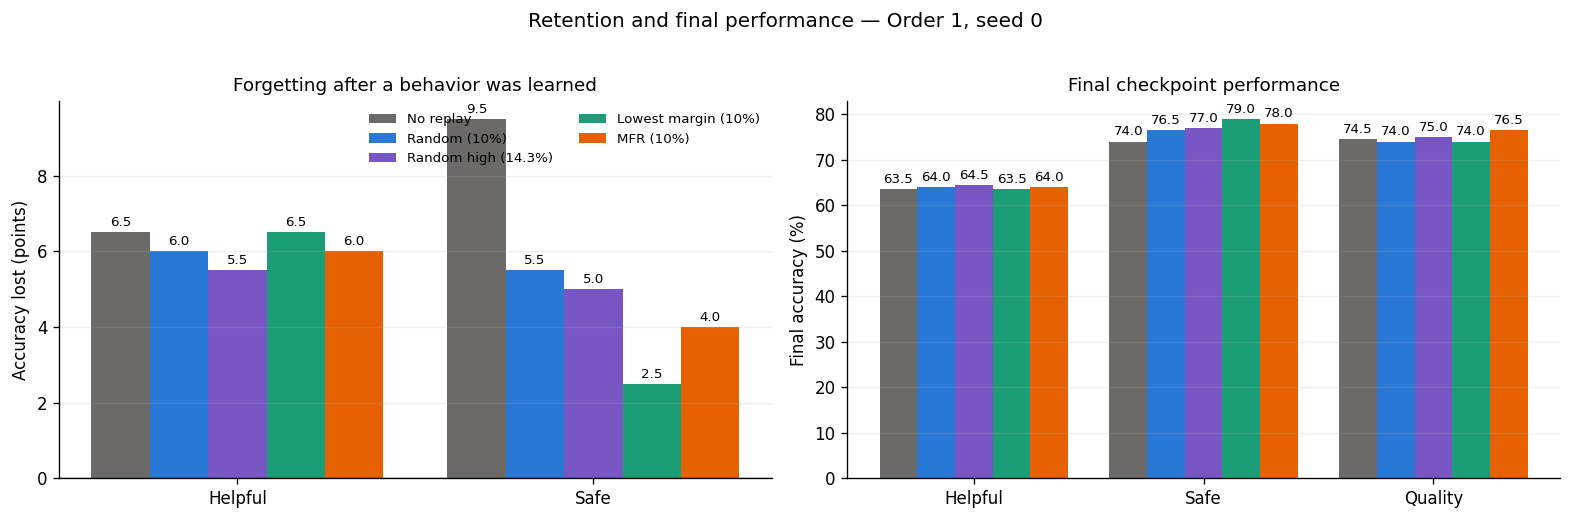

In [15]:
focus_retention = mfr_analysis.retention_table(focus, score='accuracy').copy()
focus_retention['method'] = focus_retention['method'].astype(str)
focus_retention['forgetting'] = -focus_retention['change']
forgetting = focus_retention.pivot(index='dataset', columns='method', values='forgetting')
forgetting = forgetting.reindex([d for d in protocol['orders'][str(FOCUS_ORDER)][:-1] if d in forgetting.index])
final_stage = int(focus['stage'].max())
final_scores = (focus[focus['stage'] == final_stage]
                .assign(method=lambda x: x['method'].astype(str))
                .pivot(index='eval_set', columns='method', values='accuracy')
                .reindex(['helpful', 'safe', 'quality']))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.2))
legend_methods = grouped_bars(axes[0], forgetting, 'Accuracy lost (points)',
                              'Forgetting after a behavior was learned')
axes[0].axhline(0, color='#333333', linewidth=0.8)
grouped_bars(axes[1], final_scores, 'Final accuracy (%)', 'Final checkpoint performance')
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle(f'Retention and final performance — Order {FOCUS_ORDER}, seed {FOCUS_SEED}', y=1.02)
finish_figure(fig, f'02_forgetting_and_final_o{FOCUS_ORDER}_s{FOCUS_SEED}')

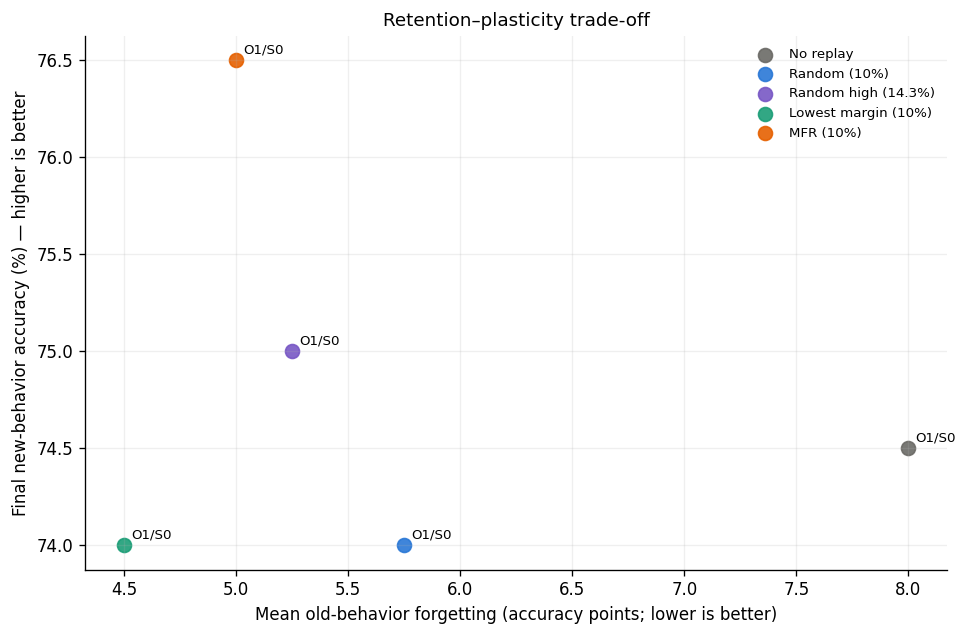

In [16]:
tradeoff = primary_summary.copy()
tradeoff['method'] = tradeoff['method'].astype(str)
tradeoff = tradeoff[tradeoff['method'].isin(available_methods(runs))]
tradeoff['mean_forgetting'] = -tradeoff['mean_retention_change']
fig, ax = plt.subplots(figsize=(8.2, 5.4))
for method in available_methods(tradeoff):
    part = tradeoff[tradeoff['method'] == method]
    ax.scatter(part['mean_forgetting'], part['final_new_stage_score'], s=70,
               color=METHOD_COLOR[method], label=METHOD_LABEL[method], alpha=0.9)
    for _, row in part.iterrows():
        ax.annotate(f"O{int(row.order_id)}/S{int(row.seed)}",
                    (row.mean_forgetting, row.final_new_stage_score),
                    xytext=(4, 4), textcoords='offset points', fontsize=8)
    if len(part) > 1:
        ax.scatter(part['mean_forgetting'].mean(), part['final_new_stage_score'].mean(),
                   marker='X', s=170, color=METHOD_COLOR[method], edgecolor='white', linewidth=1.2)
ax.set_xlabel('Mean old-behavior forgetting (accuracy points; lower is better)')
ax.set_ylabel('Final new-behavior accuracy (%) — higher is better')
ax.set_title('Retention–plasticity trade-off')
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
finish_figure(fig, '03_retention_plasticity_all_completed_cells')

,order_id,seed,dataset,method,baseline,difference_points,ci_low,ci_high,n_pairs,baseline_label
0,1,0,helpful,mfr,random,0.0,-2.0,2.0,200,Equal-budget random
1,1,0,safe,mfr,random,1.5,-0.5,4.0,200,Equal-budget random
2,1,0,helpful,mfr,random_high,-0.5,-1.5,0.0,200,Higher-budget random
3,1,0,safe,mfr,random_high,1.0,-1.5,3.5,200,Higher-budget random
4,1,0,helpful,mfr,lowest_margin,0.5,-1.5,2.5,200,Lowest current margin
5,1,0,safe,mfr,lowest_margin,-1.5,-4.0,0.5,200,Lowest current margin


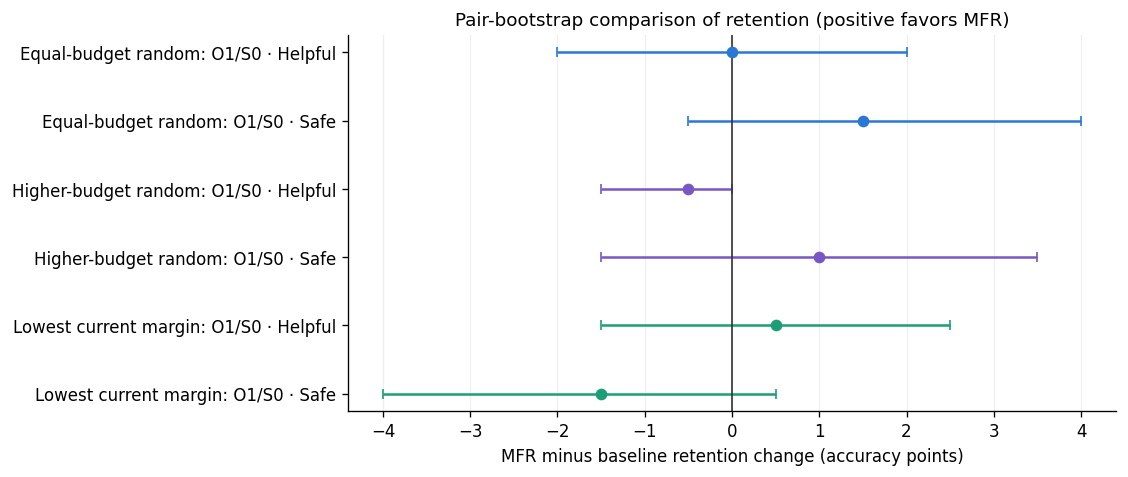

In [17]:
comparison_specs = [
    ('random', 'Equal-budget random'),
    ('random_high', 'Higher-budget random'),
    ('lowest_margin', 'Lowest current margin'),
]
comparison_frames = []
for baseline, baseline_label in comparison_specs:
    if baseline not in set(runs['method'].astype(str)):
        continue
    result = mfr_analysis.paired_retention_comparison(runs, baseline=baseline, margin='margin')
    if len(result):
        result['baseline_label'] = baseline_label
        comparison_frames.append(result)
paired = pd.concat(comparison_frames, ignore_index=True) if comparison_frames else pd.DataFrame()
display(paired.round(2))

if len(paired):
    paired = paired.sort_values(['baseline_label', 'order_id', 'seed', 'dataset']).reset_index(drop=True)
    labels = [f"{row.baseline_label}: O{int(row.order_id)}/S{int(row.seed)} · {DATASET_LABEL[row.dataset]}"
              for _, row in paired.iterrows()]
    fig, ax = plt.subplots(figsize=(9.5, max(3.4, 0.43 * len(paired) + 1.5)))
    baseline_colors = {'Equal-budget random': METHOD_COLOR['random'],
                       'Higher-budget random': METHOD_COLOR['random_high'],
                       'Lowest current margin': METHOD_COLOR['lowest_margin']}
    for i, row in paired.iterrows():
        ax.errorbar(row['difference_points'], i,
                    xerr=[[row['difference_points'] - row['ci_low']], [row['ci_high'] - row['difference_points']]],
                    fmt='o', capsize=3, color=baseline_colors[row['baseline_label']])
    ax.axvline(0, color='#333333', linewidth=1)
    ax.set_yticks(np.arange(len(paired)), labels)
    ax.invert_yaxis()
    ax.set_xlabel('MFR minus baseline retention change (accuracy points)')
    ax.set_title('Pair-bootstrap comparison of retention (positive favors MFR)')
    ax.grid(axis='x', alpha=0.2)
    finish_figure(fig, '04_paired_retention_bootstrap')
else:
    print('No matched MFR/baseline cells are available yet.')

,method,run_name,order_id,seed,steps,examples,minutes,scoring_minutes,training_minutes,replay_examples
0,none,v2_o1_none_s0,1,0,336,6000,31.27,0.00,31.27,0
1,random,v2_o1_random_s0,1,0,336,6444,33.58,0.00,33.58,444
2,random_high,v2_o1_random_high_s0,1,0,336,6666,35.22,0.00,35.22,666
3,lowest_margin,v2_o1_lowest_margin_s0,1,0,336,6444,38.25,4.38,33.87,444
4,mfr,v2_o1_mfr_s0,1,0,336,6444,37.72,4.37,33.35,444


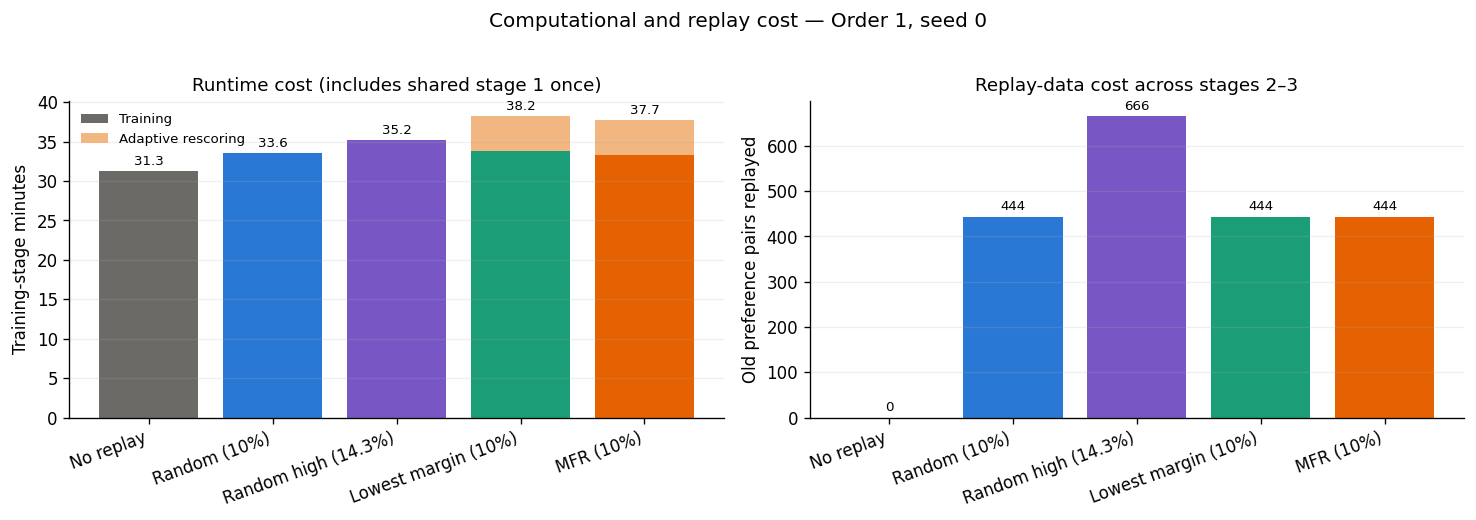

In [18]:
cost = mfr_analysis.cost_table(focus).copy()
cost['method'] = cost['method'].astype(str)
cost = cost.set_index('method').reindex(available_methods(focus)).dropna(how='all').reset_index()
base_examples = protocol['train_pairs'] * 3
cost['replay_examples'] = (cost['examples'] - base_examples).clip(lower=0)
display(cost.round(2))

x = np.arange(len(cost))
colors = [METHOD_COLOR[m] for m in cost['method']]
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
train_bars = axes[0].bar(x, cost['training_minutes'], color=colors, label='Training')
score_bars = axes[0].bar(x, cost['scoring_minutes'], bottom=cost['training_minutes'],
                         color='#f2b680', label='Adaptive rescoring')
axes[0].bar_label(score_bars, labels=[f'{v:.1f}' for v in cost['minutes']], padding=2, fontsize=8)
axes[0].set_xticks(x, [METHOD_LABEL[m] for m in cost['method']], rotation=20, ha='right')
axes[0].set_ylabel('Training-stage minutes')
axes[0].set_title('Runtime cost (includes shared stage 1 once)')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.2)
replay_bars = axes[1].bar(x, cost['replay_examples'], color=colors)
axes[1].bar_label(replay_bars, labels=[f'{int(v)}' for v in cost['replay_examples']], padding=2, fontsize=8)
axes[1].set_xticks(x, [METHOD_LABEL[m] for m in cost['method']], rotation=20, ha='right')
axes[1].set_ylabel('Old preference pairs replayed')
axes[1].set_title('Replay-data cost across stages 2–3')
axes[1].grid(axis='y', alpha=0.2)
fig.suptitle(f'Computational and replay cost — Order {FOCUS_ORDER}, seed {FOCUS_SEED}', y=1.02)
finish_figure(fig, f'05_cost_o{FOCUS_ORDER}_s{FOCUS_SEED}')

# Diagnostic figures

These explain *how* a method obtained its aggregate result. Some may belong in an appendix rather than the main report.

In [19]:
def run_metadata(frame):
    return frame.sort_values('run_name').drop_duplicates('run_name')

def clean_stage1_from(value):
    return None if value is None or pd.isna(value) else value

def load_retention_pairs(frame):
    rows = []
    for _, meta in run_metadata(frame).iterrows():
        order = list(meta['order'])
        source = clean_stage1_from(meta.get('stage1_from'))
        for learned_at, dataset in enumerate(order[:-1], start=1):
            learned = mfr_analysis.margins_at(meta['folder'], order, learned_at, dataset,
                                              stage1_from=source).reset_index()[['id', 'margin']]
            final = mfr_analysis.margins_at(meta['folder'], order, len(order), dataset,
                                            stage1_from=source).reset_index()[['id', 'margin']]
            pair = learned.merge(final, on='id', suffixes=('_learned', '_final'))
            pair['learned_correct'] = pair['margin_learned'] > 0
            pair['final_correct'] = pair['margin_final'] > 0
            pair['outcome'] = np.select(
                [pair['learned_correct'] & pair['final_correct'],
                 pair['learned_correct'] & ~pair['final_correct'],
                 ~pair['learned_correct'] & pair['final_correct']],
                ['Retained correct', 'Forgotten', 'Recovered'], default='Still incorrect')
            pair['margin_change'] = pair['margin_final'] - pair['margin_learned']
            pair['run_name'] = meta['run_name']
            pair['order_id'] = int(meta['order_id'])
            pair['seed'] = int(meta['seed'])
            pair['method'] = str(meta['method'])
            pair['dataset'] = dataset
            rows.append(pair)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def load_replay_events(frame):
    rows = []
    for _, meta in run_metadata(frame).iterrows():
        method = str(meta['method'])
        if method == 'none':
            continue
        order = list(meta['order'])
        source = clean_stage1_from(meta.get('stage1_from'))
        for stage in range(2, len(order) + 1):
            stage_dir = mfr_analysis.stage_folder(meta['folder'], order, stage, source)
            path = Path(stage_dir) / 'replay_log.csv'
            if not path.exists() or path.stat().st_size <= 1:
                continue
            try:
                log = pd.read_csv(path)
            except pd.errors.EmptyDataError:
                continue
            if len(log):
                log['run_name'] = meta['run_name']
                log['order_id'] = int(meta['order_id'])
                log['seed'] = int(meta['seed'])
                log['method'] = method
                log['stage'] = stage
                log['trained_on'] = order[stage - 1]
                log = log.rename(columns={'dataset': 'source_dataset'})
                rows.append(log)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def load_histories(frame):
    rows = []
    for _, meta in run_metadata(frame).iterrows():
        order = list(meta['order'])
        source = clean_stage1_from(meta.get('stage1_from'))
        for stage in range(2, len(order) + 1):
            stage_dir = mfr_analysis.stage_folder(meta['folder'], order, stage, source)
            path = Path(stage_dir) / 'history.csv'
            if path.exists():
                history = pd.read_csv(path)
                history['run_name'] = meta['run_name']
                history['method'] = str(meta['method'])
                history['stage'] = stage
                history['trained_on'] = order[stage - 1]
                rows.append(history)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

pair_retention = load_retention_pairs(focus)
replay_events = load_replay_events(focus)
histories = load_histories(focus)
print(f'Loaded {len(pair_retention):,} pair-retention rows, {len(replay_events):,} replay events, '
      f'and {len(histories):,} optimizer-step rows.')

Loaded 2,000 pair-retention rows, 1,998 replay events, and 1,120 optimizer-step rows.


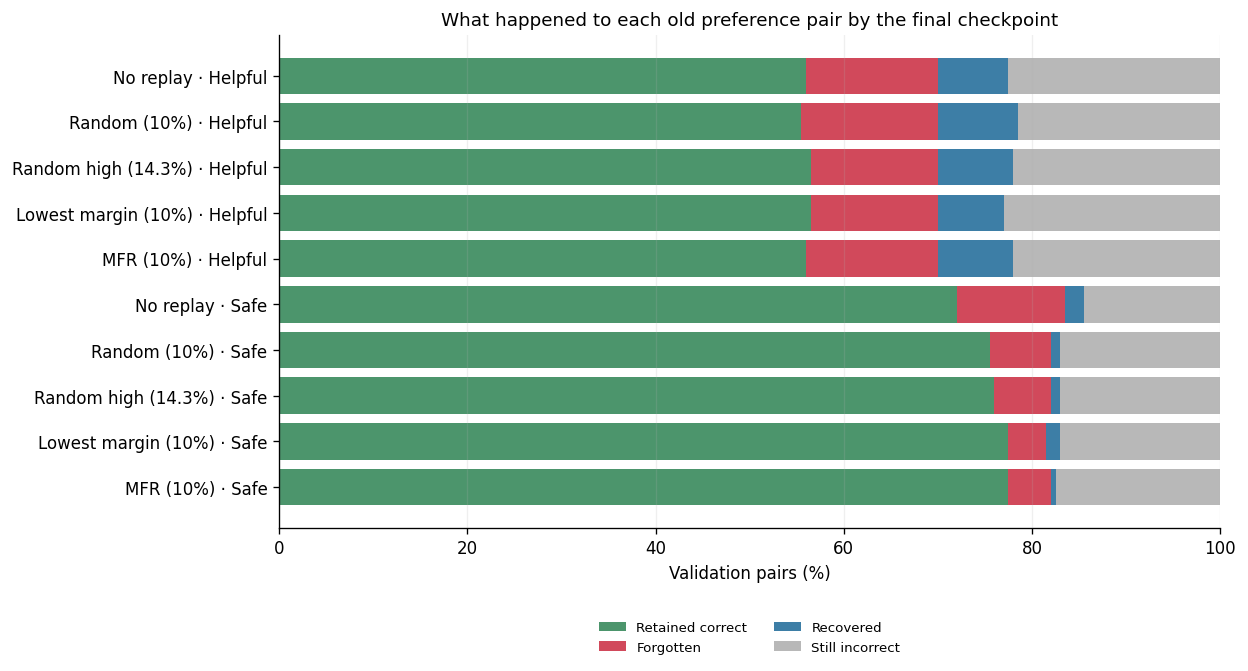

In [20]:
outcome_order = ['Retained correct', 'Forgotten', 'Recovered', 'Still incorrect']
outcome_colors = {'Retained correct': '#4c956c', 'Forgotten': '#d1495b',
                  'Recovered': '#3d7ea6', 'Still incorrect': '#b8b8b8'}
outcomes = pair_retention.groupby(['method', 'dataset', 'outcome']).size().rename('pairs').reset_index()
outcomes['percent'] = 100 * outcomes['pairs'] / outcomes.groupby(['method', 'dataset'])['pairs'].transform('sum')
outcomes['label'] = outcomes['method'].map(METHOD_LABEL) + ' · ' + outcomes['dataset'].map(DATASET_LABEL)
table = outcomes.pivot(index='label', columns='outcome', values='percent').fillna(0)
label_order = [f'{METHOD_LABEL[m]} · {DATASET_LABEL[d]}'
               for d in protocol['orders'][str(FOCUS_ORDER)][:-1] for m in available_methods(focus)]
table = table.reindex([x for x in label_order if x in table.index])
fig, ax = plt.subplots(figsize=(10.5, max(4.2, 0.43 * len(table) + 1.5)))
left = np.zeros(len(table))
for outcome in outcome_order:
    values = table[outcome].to_numpy() if outcome in table else np.zeros(len(table))
    ax.barh(np.arange(len(table)), values, left=left, color=outcome_colors[outcome], label=outcome)
    left += values
ax.set_yticks(np.arange(len(table)), table.index)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('Validation pairs (%)')
ax.set_title('What happened to each old preference pair by the final checkpoint')
ax.legend(ncol=2, fontsize=8, loc='lower center', bbox_to_anchor=(0.5, -0.28))
ax.grid(axis='x', alpha=0.2)
finish_figure(fig, f'06_pair_outcomes_o{FOCUS_ORDER}_s{FOCUS_SEED}')

/tmp/ipykernel_2439/109144898.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax.boxplot(values, patch_artist=True, showfliers=False, labels=[METHOD_LABEL[m] for m in methods],
/tmp/ipykernel_2439/109144898.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax.boxplot(values, patch_artist=True, showfliers=False, labels=[METHOD_LABEL[m] for m in methods],


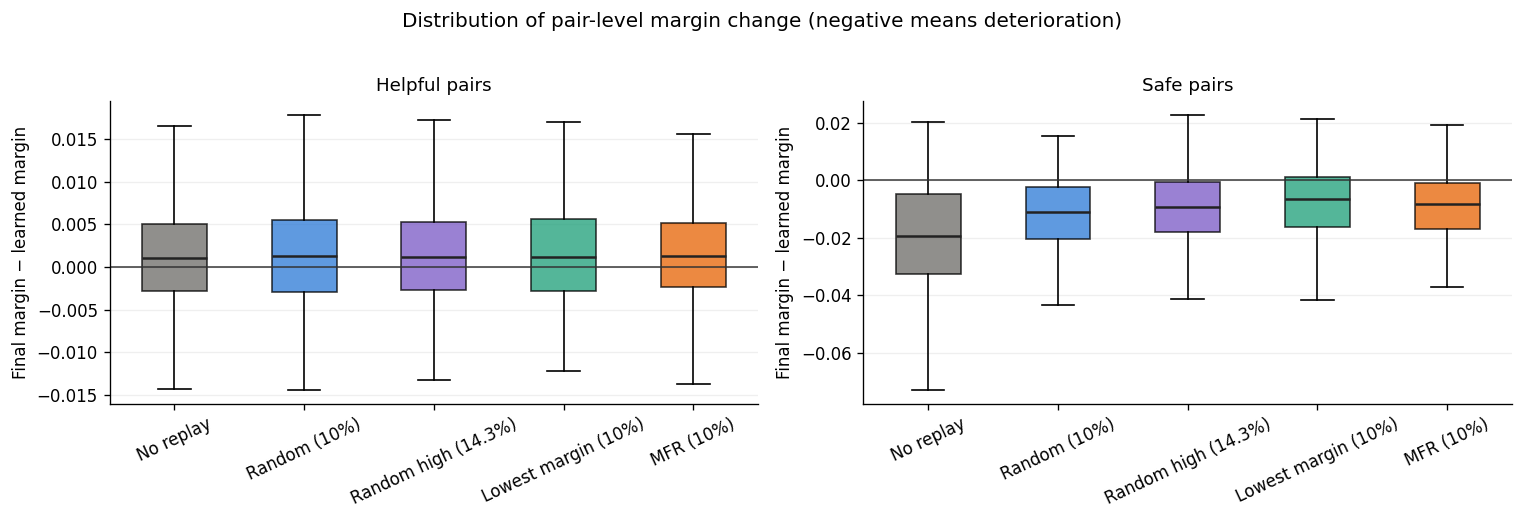

In [21]:
old_datasets = protocol['orders'][str(FOCUS_ORDER)][:-1]
fig, axes = plt.subplots(1, len(old_datasets), figsize=(12.8, 4.2), squeeze=False)
for ax, dataset in zip(axes[0], old_datasets):
    methods = available_methods(focus)
    values = [pair_retention[(pair_retention['dataset'] == dataset) &
                             (pair_retention['method'] == method)]['margin_change'].to_numpy()
              for method in methods]
    boxes = ax.boxplot(values, patch_artist=True, showfliers=False, labels=[METHOD_LABEL[m] for m in methods],
                       medianprops={'color': '#222222', 'linewidth': 1.5})
    for patch, method in zip(boxes['boxes'], methods):
        patch.set_facecolor(METHOD_COLOR[method])
        patch.set_alpha(0.75)
    ax.axhline(0, color='#333333', linewidth=0.9)
    ax.set_title(f'{DATASET_LABEL[dataset]} pairs')
    ax.set_ylabel('Final margin − learned margin')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.2)
fig.suptitle('Distribution of pair-level margin change (negative means deterioration)', y=1.02)
finish_figure(fig, f'07_margin_change_distributions_o{FOCUS_ORDER}_s{FOCUS_SEED}')

,method,stage,trained_on,slots,unique_pairs,slots_per_unique_pair,top_10pct_pair_share
0,lowest_margin,2,safe,222,132,1.68,26.58
1,lowest_margin,3,quality,222,73,3.04,18.02
2,mfr,2,safe,222,138,1.61,22.07
3,mfr,3,quality,222,108,2.06,20.27
4,random,2,safe,222,179,1.24,18.92
5,random,3,quality,222,185,1.20,19.82
6,random_high,2,safe,333,254,1.31,19.82
7,random_high,3,quality,333,261,1.28,19.82


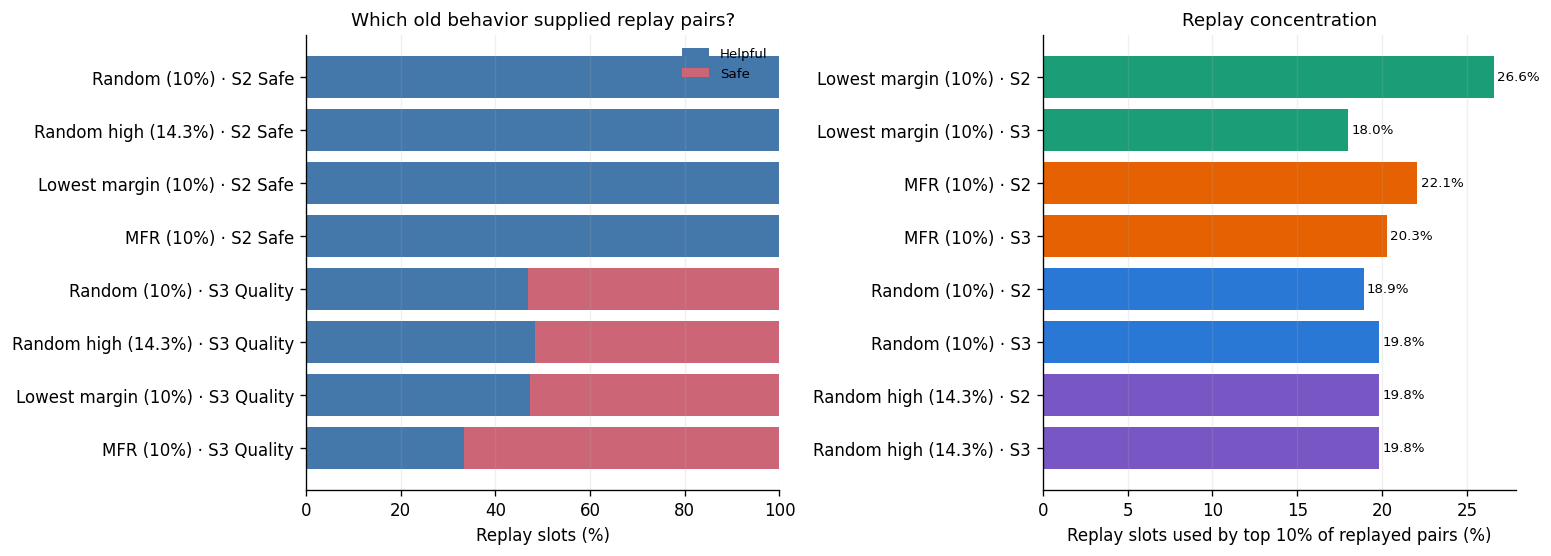

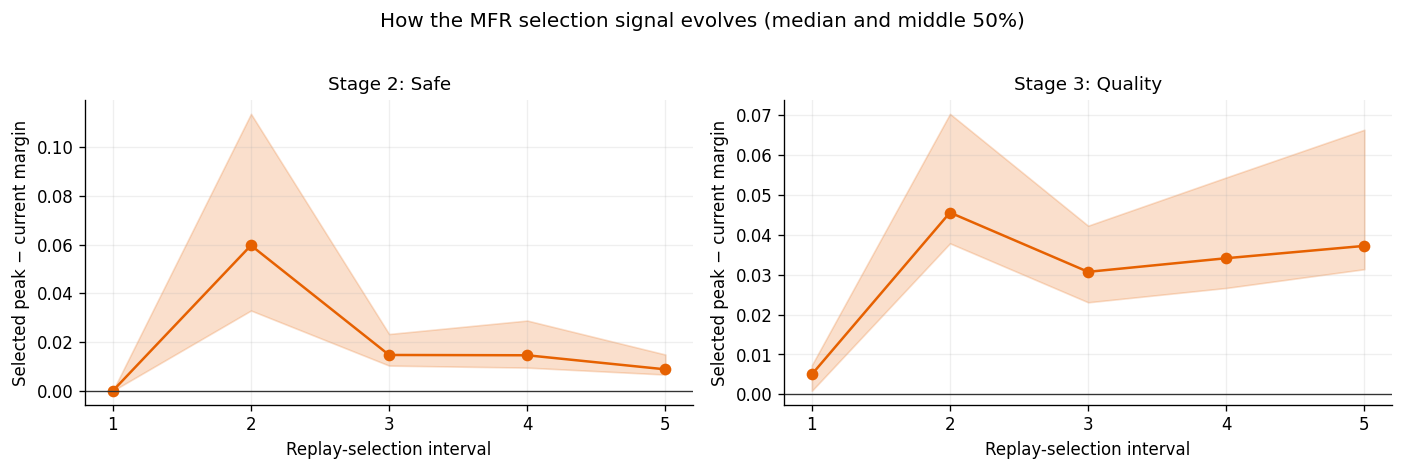

In [22]:
if replay_events.empty:
    print('No replay logs are available for this focus cell.')
else:
    replay_stats = []
    for (method, stage, trained_on), part in replay_events.groupby(['method', 'stage', 'trained_on']):
        counts = part['id'].value_counts()
        top_n = max(1, int(np.ceil(0.10 * len(counts))))
        replay_stats.append({
            'method': method, 'stage': stage, 'trained_on': trained_on, 'slots': len(part),
            'unique_pairs': part['id'].nunique(),
            'slots_per_unique_pair': len(part) / part['id'].nunique(),
            'top_10pct_pair_share': 100 * counts.nlargest(top_n).sum() / len(part),
        })
    replay_stats = pd.DataFrame(replay_stats)
    display(replay_stats.round(2))

    allocation = replay_events.groupby(['method', 'stage', 'trained_on', 'source_dataset']).size().rename('slots').reset_index()
    allocation['share'] = 100 * allocation['slots'] / allocation.groupby(
        ['method', 'stage', 'trained_on'])['slots'].transform('sum')
    allocation['label'] = allocation.apply(
        lambda r: f"{METHOD_LABEL[r['method']]} · S{int(r['stage'])} {DATASET_LABEL[r['trained_on']]}", axis=1)
    alloc_table = allocation.pivot(index='label', columns='source_dataset', values='share').fillna(0)
    desired = [f'{METHOD_LABEL[m]} · S{s} {DATASET_LABEL[protocol["orders"][str(FOCUS_ORDER)][s-1]]}'
               for s in (2, 3) for m in available_methods(focus) if m != 'none']
    alloc_table = alloc_table.reindex([x for x in desired if x in alloc_table.index])

    fig, axes = plt.subplots(1, 2, figsize=(13.0, max(4.2, 0.38 * len(alloc_table) + 1.7)))
    left = np.zeros(len(alloc_table))
    source_colors = {'helpful': '#4477aa', 'safe': '#cc6677', 'quality': '#228833'}
    for dataset in ['helpful', 'safe', 'quality']:
        if dataset not in alloc_table:
            continue
        values = alloc_table[dataset].to_numpy()
        axes[0].barh(np.arange(len(alloc_table)), values, left=left,
                     color=source_colors[dataset], label=DATASET_LABEL[dataset])
        left += values
    axes[0].set_yticks(np.arange(len(alloc_table)), alloc_table.index)
    axes[0].invert_yaxis()
    axes[0].set_xlim(0, 100)
    axes[0].set_xlabel('Replay slots (%)')
    axes[0].set_title('Which old behavior supplied replay pairs?')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='x', alpha=0.2)

    stat_labels = replay_stats.apply(lambda r: f"{METHOD_LABEL[r['method']]} · S{int(r['stage'])}", axis=1)
    stat_colors = [METHOD_COLOR[m] for m in replay_stats['method']]
    bars = axes[1].barh(np.arange(len(replay_stats)), replay_stats['top_10pct_pair_share'], color=stat_colors)
    axes[1].bar_label(bars, labels=[f'{v:.1f}%' for v in replay_stats['top_10pct_pair_share']],
                      padding=2, fontsize=8)
    axes[1].set_yticks(np.arange(len(replay_stats)), stat_labels)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Replay slots used by top 10% of replayed pairs (%)')
    axes[1].set_title('Replay concentration')
    axes[1].grid(axis='x', alpha=0.2)
    finish_figure(fig, f'08_replay_allocation_concentration_o{FOCUS_ORDER}_s{FOCUS_SEED}')

    mfr_events = replay_events[replay_events['method'] == 'mfr'].copy()
    if len(mfr_events) and 'selection_score' in mfr_events:
        evolution = (mfr_events.groupby(['stage', 'trained_on', 'interval'])['selection_score']
                     .agg(median='median', q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75))
                     .reset_index())
        fig, axes = plt.subplots(1, evolution['stage'].nunique(), figsize=(11.8, 3.8), squeeze=False)
        for ax, (stage, part) in zip(axes[0], evolution.groupby('stage')):
            ax.plot(part['interval'], part['median'], marker='o', color=METHOD_COLOR['mfr'])
            ax.fill_between(part['interval'], part['q25'], part['q75'], color=METHOD_COLOR['mfr'], alpha=0.2)
            ax.axhline(0, color='#333333', linewidth=0.8)
            ax.set_xticks(sorted(part['interval'].unique()))
            ax.set_xlabel('Replay-selection interval')
            ax.set_ylabel('Selected peak − current margin')
            ax.set_title(f"Stage {int(stage)}: {DATASET_LABEL[part['trained_on'].iloc[0]]}")
            ax.grid(alpha=0.2)
        fig.suptitle('How the MFR selection signal evolves (median and middle 50%)', y=1.02)
        finish_figure(fig, f'09_mfr_score_evolution_o{FOCUS_ORDER}_s{FOCUS_SEED}')

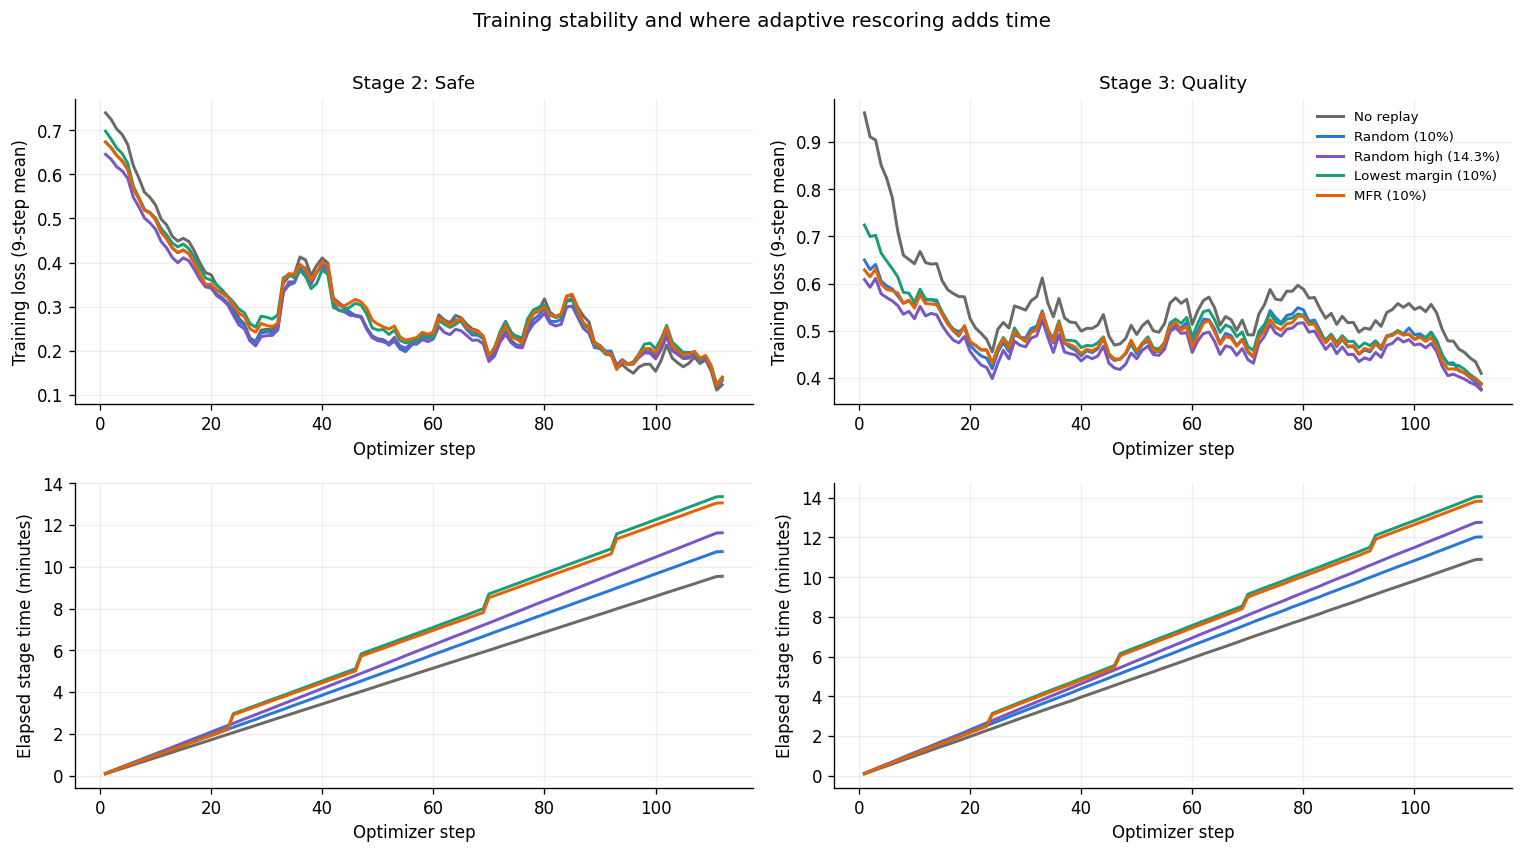

In [23]:
if histories.empty:
    print('No history files are available for this focus cell.')
else:
    stages = sorted(histories['stage'].unique())
    fig, axes = plt.subplots(2, len(stages), figsize=(12.8, 7.0), squeeze=False)
    for col, stage in enumerate(stages):
        stage_data = histories[histories['stage'] == stage]
        for method in available_methods(focus):
            part = stage_data[stage_data['method'] == method].sort_values('step').copy()
            if part.empty:
                continue
            part['loss_smooth'] = part['loss'].rolling(9, center=True, min_periods=1).mean()
            axes[0, col].plot(part['step'], part['loss_smooth'], color=METHOD_COLOR[method],
                              label=METHOD_LABEL[method], linewidth=1.8)
            axes[1, col].plot(part['step'], part['minutes'], color=METHOD_COLOR[method], linewidth=1.8)
        trained_on = stage_data['trained_on'].iloc[0]
        axes[0, col].set_title(f'Stage {int(stage)}: {DATASET_LABEL[trained_on]}')
        axes[0, col].set_xlabel('Optimizer step')
        axes[0, col].set_ylabel('Training loss (9-step mean)')
        axes[1, col].set_xlabel('Optimizer step')
        axes[1, col].set_ylabel('Elapsed stage time (minutes)')
        axes[0, col].grid(alpha=0.2)
        axes[1, col].grid(alpha=0.2)
    axes[0, -1].legend(fontsize=8)
    fig.suptitle('Training stability and where adaptive rescoring adds time', y=1.01)
    finish_figure(fig, f'10_training_diagnostics_o{FOCUS_ORDER}_s{FOCUS_SEED}')

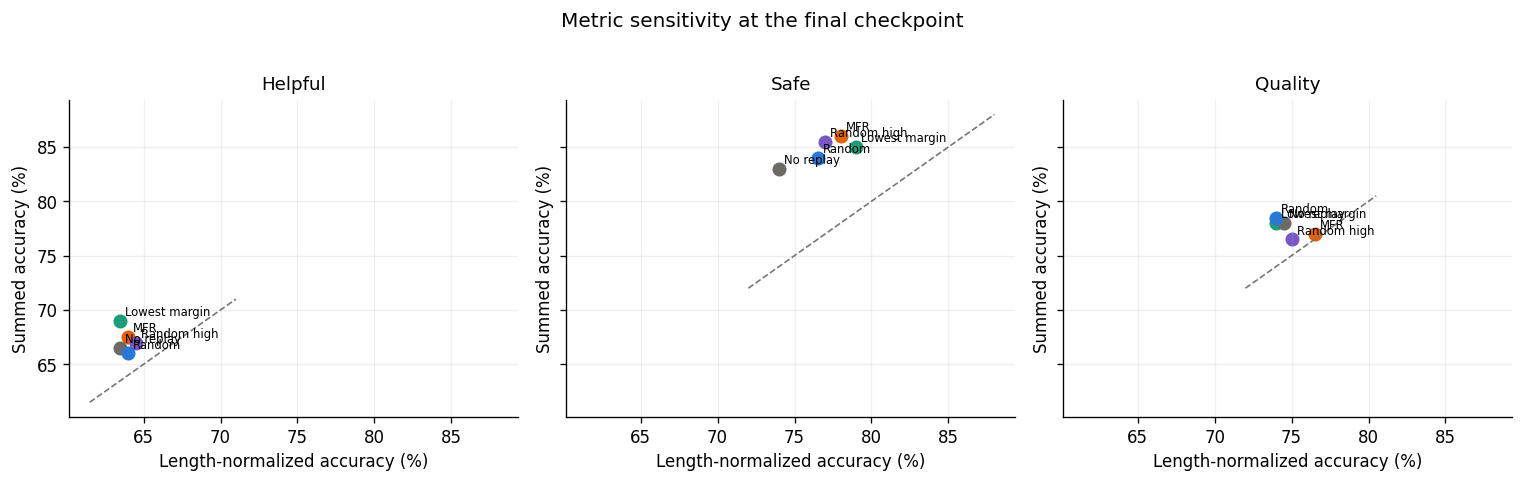

In [24]:
final_rows = focus[focus['stage'] == focus['stage'].max()].copy()
final_rows['method'] = final_rows['method'].astype(str)
fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.9), sharex=True, sharey=True)
for ax, dataset in zip(axes, ['helpful', 'safe', 'quality']):
    part = final_rows[final_rows['eval_set'] == dataset]
    low = min(part['accuracy'].min(), part['accuracy_sum'].min()) - 2
    high = max(part['accuracy'].max(), part['accuracy_sum'].max()) + 2
    ax.plot([low, high], [low, high], color='#777777', linestyle='--', linewidth=1)
    for _, row in part.iterrows():
        method = row['method']
        ax.scatter(row['accuracy'], row['accuracy_sum'], color=METHOD_COLOR[method], s=55)
        short = METHOD_LABEL[method].replace(' (10%)', '').replace(' (14.3%)', '')
        ax.annotate(short, (row['accuracy'], row['accuracy_sum']), xytext=(3, 3),
                    textcoords='offset points', fontsize=7)
    ax.set_title(DATASET_LABEL[dataset])
    ax.set_xlabel('Length-normalized accuracy (%)')
    ax.set_ylabel('Summed accuracy (%)')
    ax.grid(alpha=0.2)
fig.suptitle('Metric sensitivity at the final checkpoint', y=1.02)
finish_figure(fig, f'11_metric_sensitivity_o{FOCUS_ORDER}_s{FOCUS_SEED}')